In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
data = pd.read_csv("/content/Food_Delivery_Time_Prediction.csv")

In [34]:
data["Delivery_Speed"] = data["Distance"]/(data["Delivery_Time"]/60)

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Weather_Conditions'] = le.fit_transform(data['Weather_Conditions'])
data['Traffic_Conditions'] = le.fit_transform(data['Traffic_Conditions'])
data['Vehicle_Type'] = le.fit_transform(data['Vehicle_Type'])

In [36]:
med = data["Delivery_Speed"].median()
data["fast/delay"] = (data["Delivery_Speed"]>med).astype(int)

In [37]:
from sklearn.preprocessing import MinMaxScaler
data_scaler = MinMaxScaler()
data[['Distance','Delivery_Time']] = data_scaler.fit_transform(data[['Distance','Delivery_Time']])

In [38]:
#sir no need for haverserine as i think distance will do the work useless features will only make us waste our time

In [39]:
data.drop(columns=["Order_ID","Customer_Location","Restaurant_Location"],axis=1,inplace=True)
data['Order_Priority'] = le.fit_transform(data['Order_Priority'])
data['Order_Time'] = le.fit_transform(data['Order_Time'])

In [40]:
x = data.drop(columns=["Delivery_Speed","fast/delay","Delivery_Time"],axis=1)
y = data["fast/delay"]

In [41]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train,y_train)
nb_pred = nb.predict(x_test)
scaler = MinMaxScaler()

In [42]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Naive bayes Classifer predicted this data:")
print("Accuarcy:",accuracy_score(y_test,nb_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,nb_pred))
print("Classification Report:\n",classification_report(y_test,nb_pred))

Naive bayes Classifer predicted this data:
Accuarcy: 0.925
Confusion Matrix:
 [[18  2]
 [ 1 19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.92        20
           1       0.90      0.95      0.93        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
params = {
    "n_neighbors": range(1, 31),
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}
grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(x_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
knn = KNeighborsClassifier(n_neighbors=13,p=2,weights="uniform")
knn.fit(x_train,y_train)
knn_pred = knn.predict(x_test)
print("This is the prediction of KNN Classifier:")
print("Accuarcy:",accuracy_score(y_test,knn_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,knn_pred))
print("Classification Report:\n",classification_report(y_test,knn_pred))

Best Parameters: {'n_neighbors': 13, 'p': 2, 'weights': 'uniform'}
Best CV Accuracy: 0.75625
This is the prediction of KNN Classifier:
Accuarcy: 0.5
Confusion Matrix:
 [[11  9]
 [11  9]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.55      0.52        20
           1       0.50      0.45      0.47        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.50        40
weighted avg       0.50      0.50      0.50        40



In [44]:
from sklearn.tree import DecisionTreeClassifier
params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"]
}
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(x_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

Best parameters: {'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best score: 0.84375


In [45]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=3,criterion='entropy',min_samples_split=3,min_samples_leaf=4)
dt.fit(x_train,y_train)
dt_pred = dt.predict(x_test)
print("This is the prediction of Decision Tree Classifier:")
print("Accuarcy:",accuracy_score(y_test,dt_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,dt_pred))
print("Classification Report:",classification_report(y_test,dt_pred))

This is the prediction of Decision Tree Classifier:
Accuarcy: 0.85
Confusion Matrix:
 [[18  2]
 [ 4 16]]
Classification Report:               precision    recall  f1-score   support

           0       0.82      0.90      0.86        20
           1       0.89      0.80      0.84        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



In [46]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "KNN", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, dt_pred)
    ],
    "Recall": [
        recall_score(y_test, nb_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, dt_pred)
    ],
    "F1-Score": [
        f1_score(y_test, nb_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, dt_pred)
    ]
})
print(results)

           Model  Accuracy  Precision  Recall  F1-Score
0    Naive Bayes     0.925   0.904762    0.95  0.926829
1            KNN     0.500   0.500000    0.45  0.473684
2  Decision Tree     0.850   0.888889    0.80  0.842105


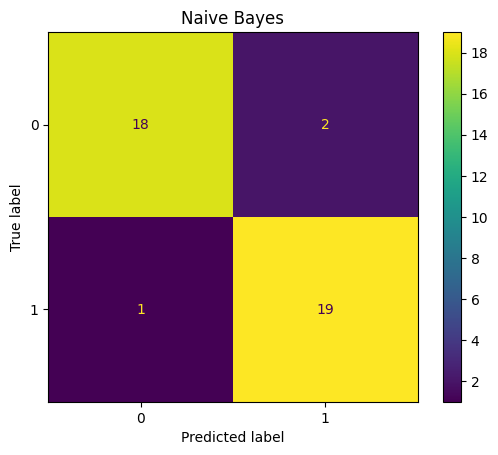

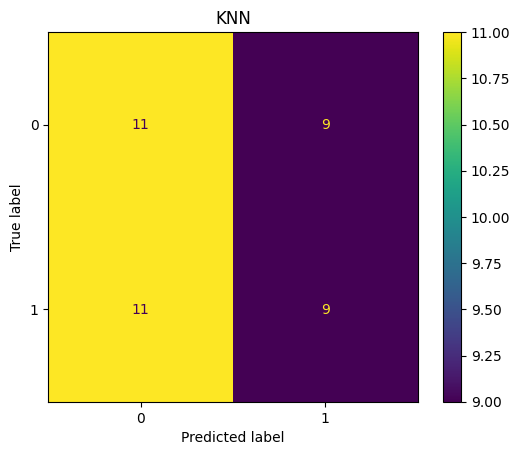

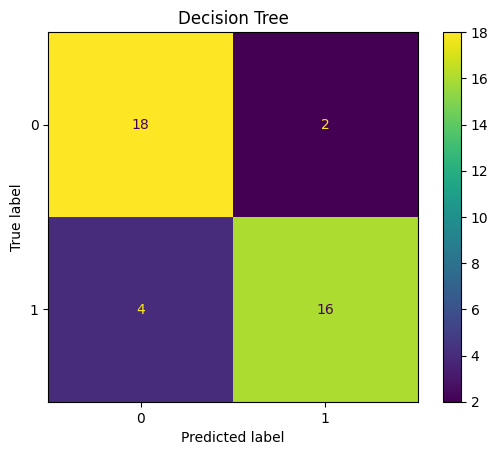

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
models = {
    "Naive Bayes": nb_pred,
    "KNN": knn_pred,
    "Decision Tree": dt_pred
}
for name, pred in models.items():
    ConfusionMatrixDisplay.from_predictions(y_test, pred)
    plt.title(name)
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


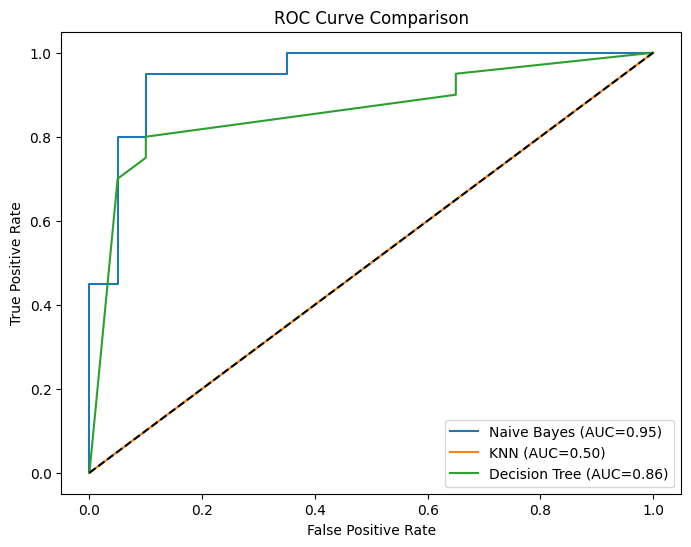

In [48]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
fpr, tpr, _ = roc_curve(y_test, nb.predict_proba(x_test)[:,1])
plt.plot(fpr, tpr, label=f"Naive Bayes (AUC={auc(fpr,tpr):.2f})")
fpr, tpr, _ = roc_curve(y_test, knn.predict_proba(x_test_scaled)[:,1])
plt.plot(fpr, tpr, label=f"KNN (AUC={auc(fpr,tpr):.2f})")
fpr, tpr, _ = roc_curve(y_test, dt.predict_proba(x_test)[:,1])
plt.plot(fpr, tpr, label=f"Decision Tree (AUC={auc(fpr,tpr):.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()